# Car Price Prediction with Machine Learning


---
##  Define the Problem
**Objective:** Predict the **selling price** of a used car based on its attributes such as brand, year, mileage, fuel type, and transmission.

**Problem Type:** Supervised Learning → **Regression**

**Target Variable:** `Selling_Price` (in Lakhs INR)

**Evaluation Metrics:** MAE, RMSE, R² Score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
df = pd.read_csv('car data.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [3]:
print(' Dataset Info')
df.info()

 Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Total missing values: 0


In [6]:
print('=== Duplicate Rows ===')
print(f'Number of duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

=== Duplicate Rows ===
Number of duplicate rows: 2
Shape after removing duplicates: (299, 9)


In [7]:
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

=== Unique Values per Column ===
Car_Name: 98 unique values
Year: 16 unique values
Selling_Price: 156 unique values
Present_Price: 148 unique values
Driven_kms: 206 unique values
Fuel_Type: 3 unique values
Selling_type: 2 unique values
Transmission: 2 unique values
Owner: 3 unique values


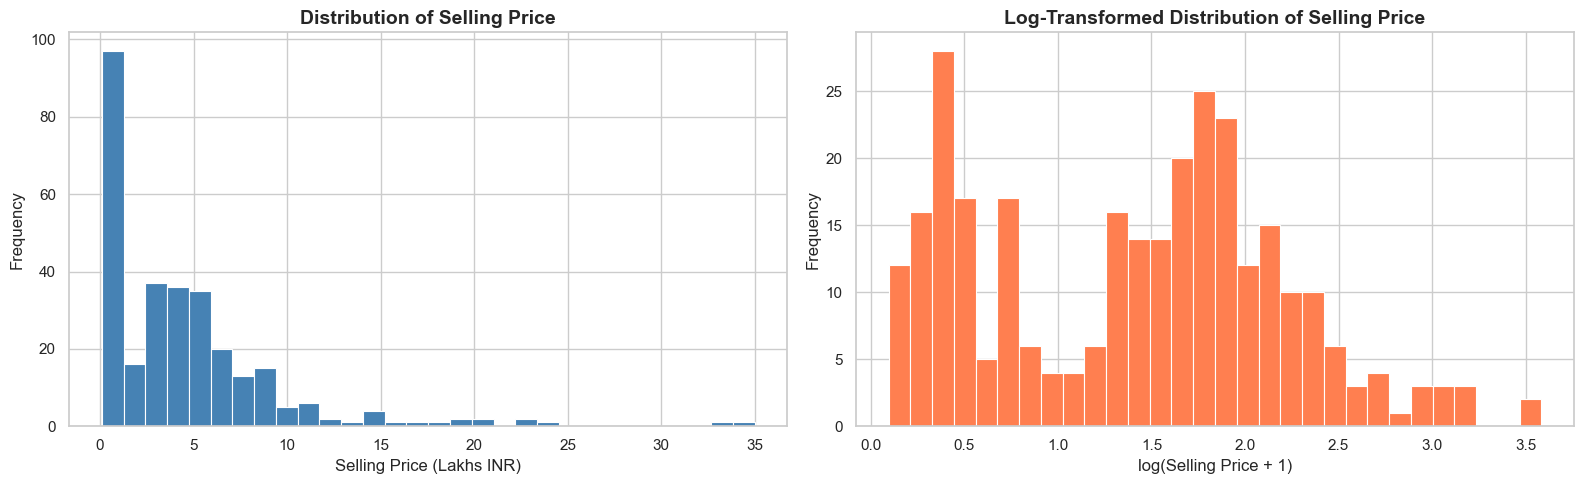

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Selling Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Selling_Price']), bins=30, color='coral', edgecolor='white', linewidth=0.8)
axes[1].set_title('Log-Transformed Distribution of Selling Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Selling Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

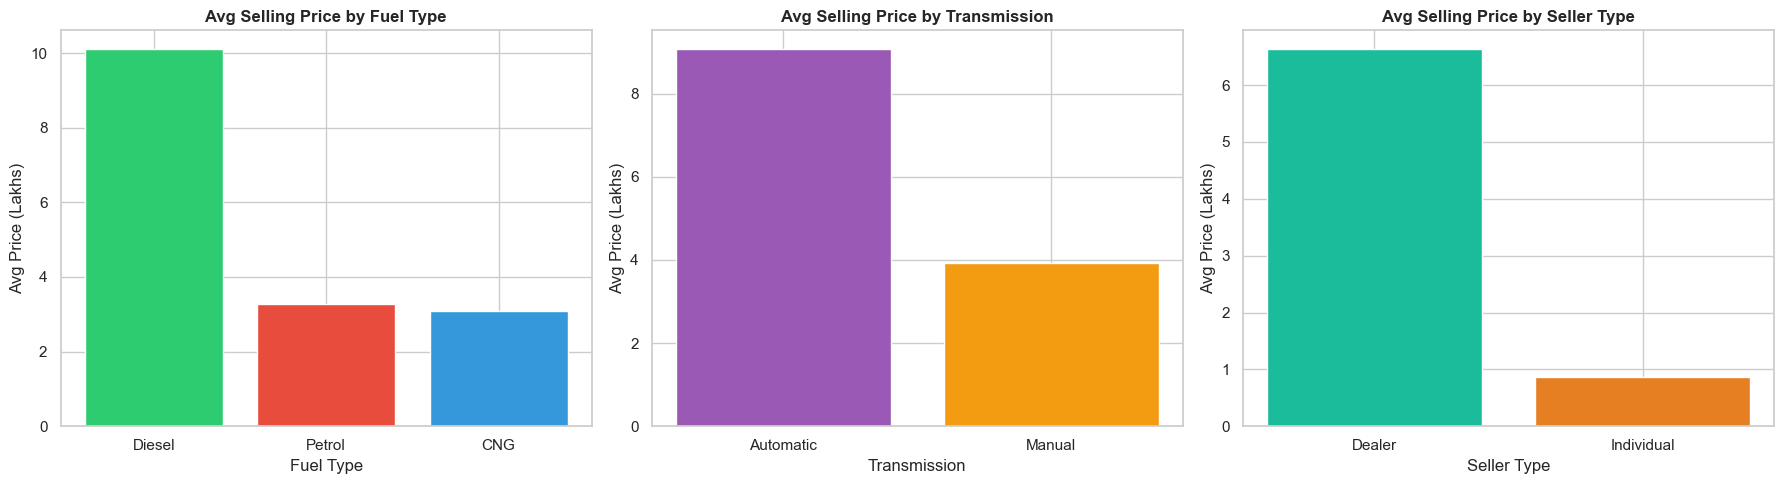

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fuel_avg = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
axes[0].bar(fuel_avg.index, fuel_avg.values, color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('Avg Selling Price by Fuel Type', fontweight='bold')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Avg Price (Lakhs)')

trans_avg = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
axes[1].bar(trans_avg.index, trans_avg.values, color=['#9b59b6', '#f39c12'], edgecolor='white')
axes[1].set_title('Avg Selling Price by Transmission', fontweight='bold')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Avg Price (Lakhs)')

seller_avg = df.groupby('Selling_type')['Selling_Price'].mean().sort_values(ascending=False)
axes[2].bar(seller_avg.index, seller_avg.values, color=['#1abc9c', '#e67e22'], edgecolor='white')
axes[2].set_title('Avg Selling Price by Seller Type', fontweight='bold')
axes[2].set_xlabel('Seller Type')
axes[2].set_ylabel('Avg Price (Lakhs)')

plt.tight_layout()
plt.show()

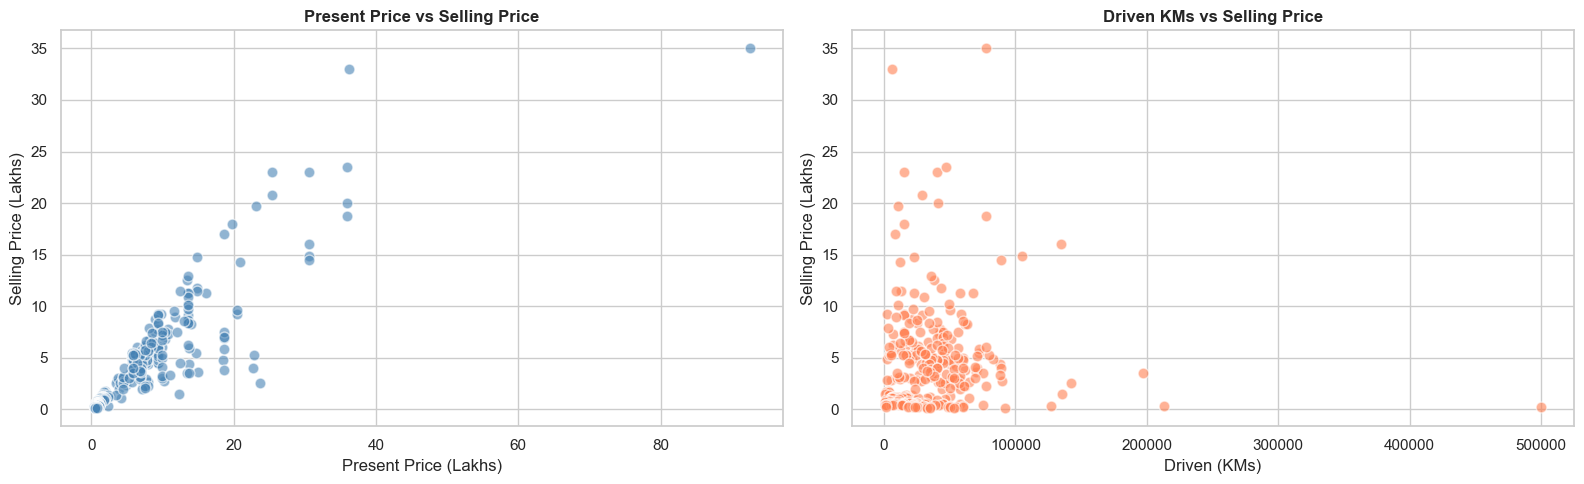

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='steelblue', edgecolors='white', s=60)
axes[0].set_title('Present Price vs Selling Price', fontweight='bold')
axes[0].set_xlabel('Present Price (Lakhs)')
axes[0].set_ylabel('Selling Price (Lakhs)')

axes[1].scatter(df['Driven_kms'], df['Selling_Price'], alpha=0.6, color='coral', edgecolors='white', s=60)
axes[1].set_title('Driven KMs vs Selling Price', fontweight='bold')
axes[1].set_xlabel('Driven (KMs)')
axes[1].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

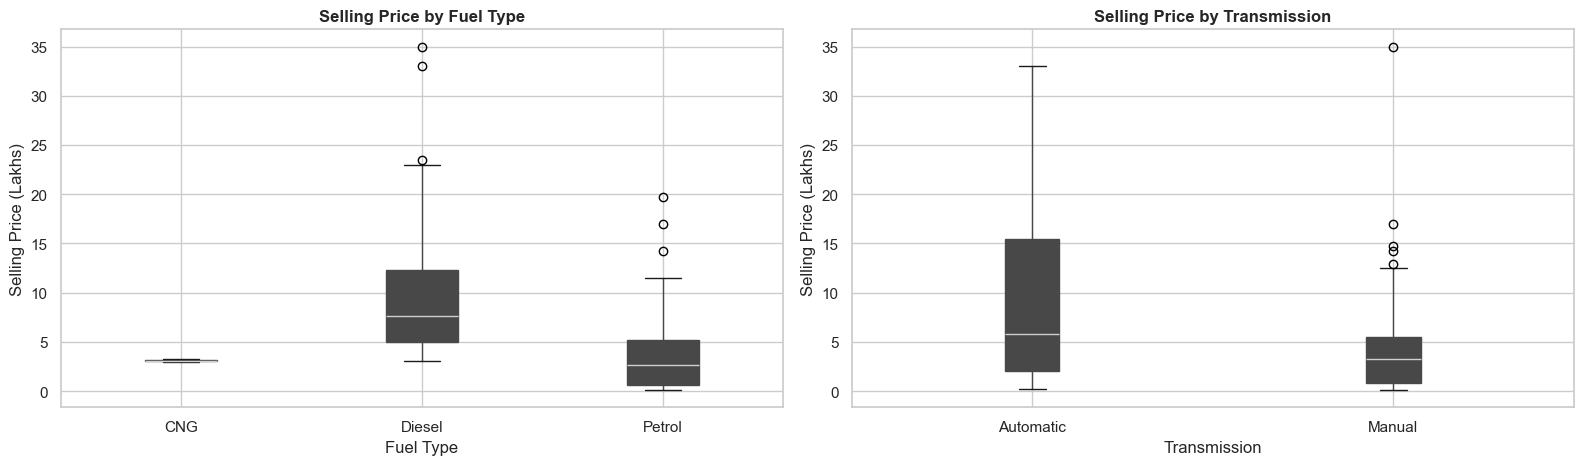

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.boxplot(column='Selling_Price', by='Fuel_Type', ax=axes[0], patch_artist=True)
axes[0].set_title('Selling Price by Fuel Type', fontweight='bold')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Selling Price (Lakhs)')
plt.sca(axes[0])
plt.suptitle('')

df.boxplot(column='Selling_Price', by='Transmission', ax=axes[1], patch_artist=True)
axes[1].set_title('Selling Price by Transmission', fontweight='bold')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Selling Price (Lakhs)')
plt.sca(axes[1])
plt.suptitle('')

plt.tight_layout()
plt.show()

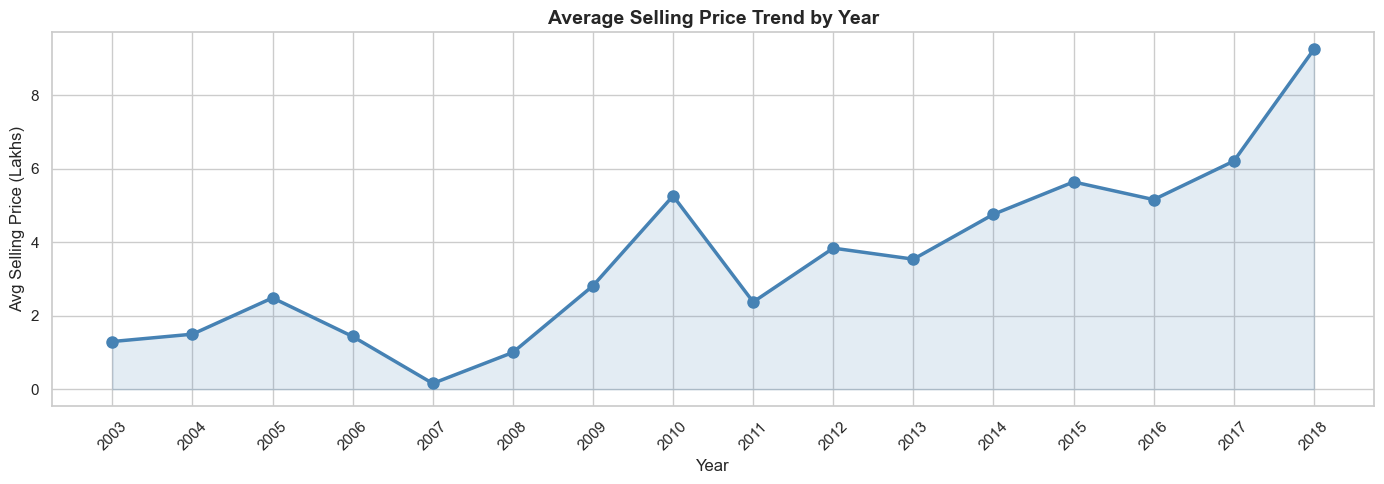

In [12]:
year_avg = df.groupby('Year')['Selling_Price'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(year_avg['Year'], year_avg['Selling_Price'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(year_avg['Year'], year_avg['Selling_Price'], alpha=0.15, color='steelblue')
plt.title('Average Selling Price Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Avg Selling Price (Lakhs)')
plt.xticks(year_avg['Year'], rotation=45)
plt.tight_layout()
plt.show()

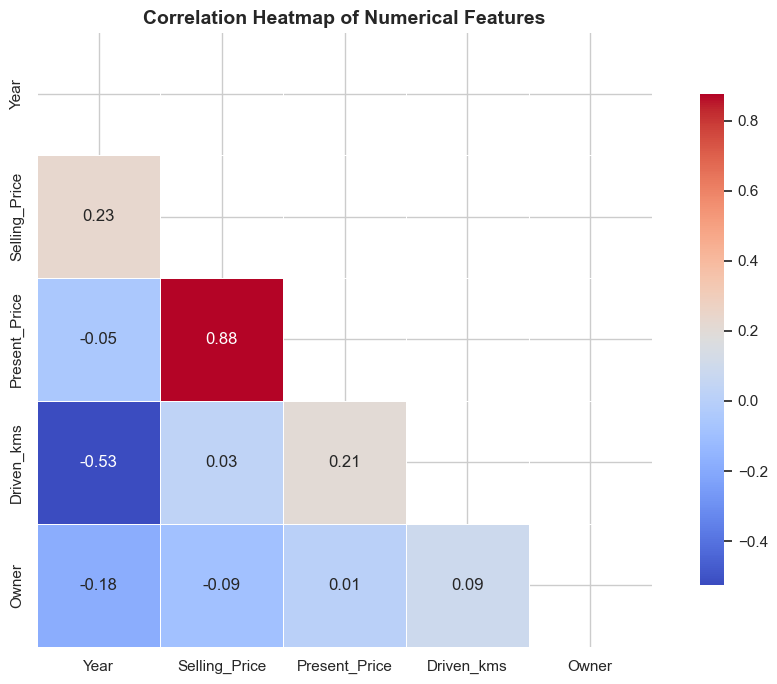

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8}, square=True
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

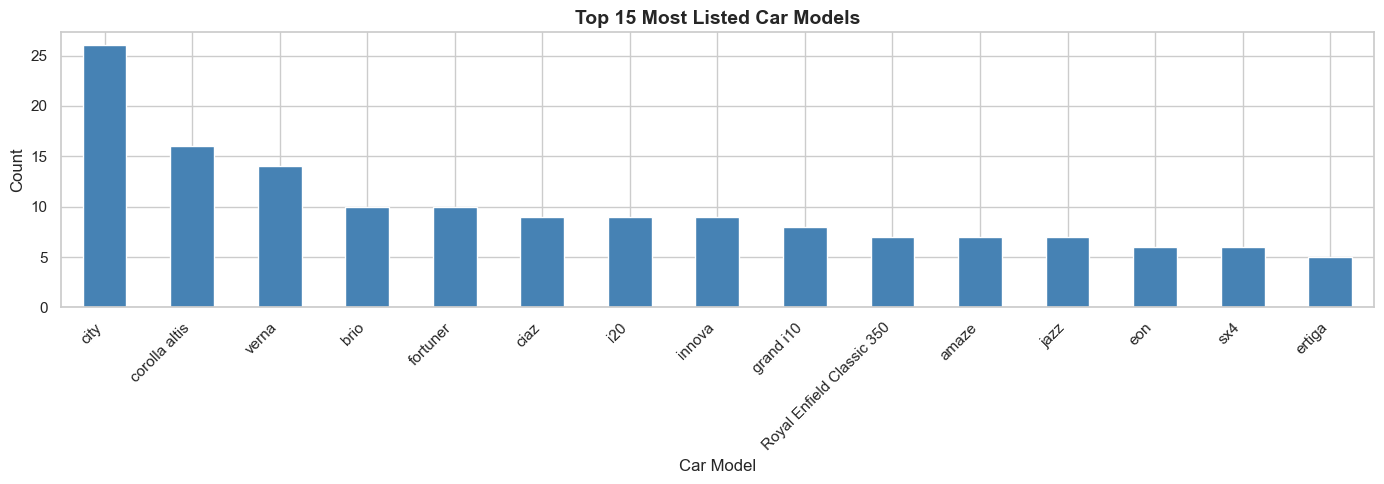

In [14]:
top_cars = df['Car_Name'].value_counts().head(15)

plt.figure(figsize=(14, 5))
top_cars.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Most Listed Car Models', fontsize=14, fontweight='bold')
plt.xlabel('Car Model')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
##  Feature Engineering

In [15]:
df_fe = df.copy()

current_year = 2024
df_fe['Car_Age'] = current_year - df_fe['Year']

df_fe['Price_Depreciation'] = df_fe['Present_Price'] - df_fe['Selling_Price']

df_fe['Depreciation_Rate'] = (df_fe['Price_Depreciation'] / df_fe['Present_Price']) * 100

df_fe['KMs_per_Year'] = df_fe['Driven_kms'] / (df_fe['Car_Age'] + 1)

print('New features added: Car_Age, Price_Depreciation, Depreciation_Rate, KMs_per_Year')
df_fe[['Car_Name', 'Year', 'Car_Age', 'Price_Depreciation', 'Depreciation_Rate', 'KMs_per_Year', 'Selling_Price']].head(8)

New features added: Car_Age, Price_Depreciation, Depreciation_Rate, KMs_per_Year


,Car_Name,Year,Car_Age,Price_Depreciation,Depreciation_Rate,KMs_per_Year,Selling_Price
0,ritz,2014,10,2.24,40.071556,2454.545455,3.35
1,sx4,2013,11,4.79,50.209644,3583.333333,4.75
2,ciaz,2017,7,2.60,26.395939,862.500000,7.25
3,wagon r,2011,13,1.30,31.325301,371.428571,2.85
4,swift,2014,10,2.27,33.042213,3859.090909,4.60
5,vitara brezza,2018,6,0.58,5.900305,295.857143,9.25
6,ciaz,2015,9,1.37,16.871921,1879.600000,6.75
7,s cross,2015,9,2.11,24.506388,3342.900000,6.50


In [16]:
le = LabelEncoder()

categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_cols:
    df_fe[col + '_Encoded'] = le.fit_transform(df_fe[col])
    print(f'{col} encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_fe.drop(columns=['Car_Name', 'Year', 'Fuel_Type', 'Selling_type', 'Transmission'], inplace=True)

print(f'\nFinal feature set shape: {df_fe.shape}')
df_fe.head(5)

Fuel_Type encoding: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
Selling_type encoding: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
Transmission encoding: {'Automatic': np.int64(0), 'Manual': np.int64(1)}

Final feature set shape: (299, 11)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Price_Depreciation,Depreciation_Rate,KMs_per_Year,Fuel_Type_Encoded,Selling_type_Encoded,Transmission_Encoded
0,3.35,5.59,27000,0,10,2.24,40.071556,2454.545455,2,0,1
1,4.75,9.54,43000,0,11,4.79,50.209644,3583.333333,1,0,1
2,7.25,9.85,6900,0,7,2.60,26.395939,862.500000,2,0,1
3,2.85,4.15,5200,0,13,1.30,31.325301,371.428571,2,0,1
4,4.60,6.87,42450,0,10,2.27,33.042213,3859.090909,1,0,1


In [17]:
print('=== Final Feature Columns ===')
for col in df_fe.columns:
    print(f'  - {col}')

=== Final Feature Columns ===
  - Selling_Price
  - Present_Price
  - Driven_kms
  - Owner
  - Car_Age
  - Price_Depreciation
  - Depreciation_Rate
  - KMs_per_Year
  - Fuel_Type_Encoded
  - Selling_type_Encoded
  - Transmission_Encoded


In [18]:
X = df_fe.drop(columns=['Selling_Price'])
y = df_fe['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Total samples      : {len(df_fe)}')
print(f'Training samples   : {X_train.shape[0]} ({X_train.shape[0]/len(df_fe)*100:.1f}%)')
print(f'Testing samples    : {X_test.shape[0]} ({X_test.shape[0]/len(df_fe)*100:.1f}%)')
print(f'Number of features : {X_train.shape[1]}')
print(f'Feature names      : {list(X.columns)}')

Total samples      : 299
Training samples   : 239 (79.9%)
Testing samples    : 60 (20.1%)
Number of features : 10
Feature names      : ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Price_Depreciation', 'Depreciation_Rate', 'KMs_per_Year', 'Fuel_Type_Encoded', 'Selling_type_Encoded', 'Transmission_Encoded']


---
##  Choose a Model

We will evaluate three models:
1. **Linear Regression** — Simple baseline model
2. **Random Forest Regressor** — Ensemble tree-based model
3. **Gradient Boosting Regressor** — Advanced boosting model

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print('Models selected for comparison:')
for name in models:
    print(f'  - {name}')

Models selected for comparison:
  - Linear Regression
  - Random Forest
  - Gradient Boosting


---
## Train the Model

In [20]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅ {name} — Training complete')

✅ Linear Regression — Training complete
✅ Random Forest — Training complete
✅ Gradient Boosting — Training complete


---
## Evaluate the Model

In [22]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4),
        'CV R² Mean': round(cv_mean, 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(' Model Evaluation Results ')
results_df

 Model Evaluation Results 


,MAE,MSE,RMSE,R² Score,CV R² Mean
Model,,,,,
Linear Regression,0.0000,0.0000,0.0000,1.0000,1.0000
Random Forest,1.3379,15.5335,3.9412,0.3973,0.5674
Gradient Boosting,1.2004,12.2600,3.5014,0.5243,-0.4557


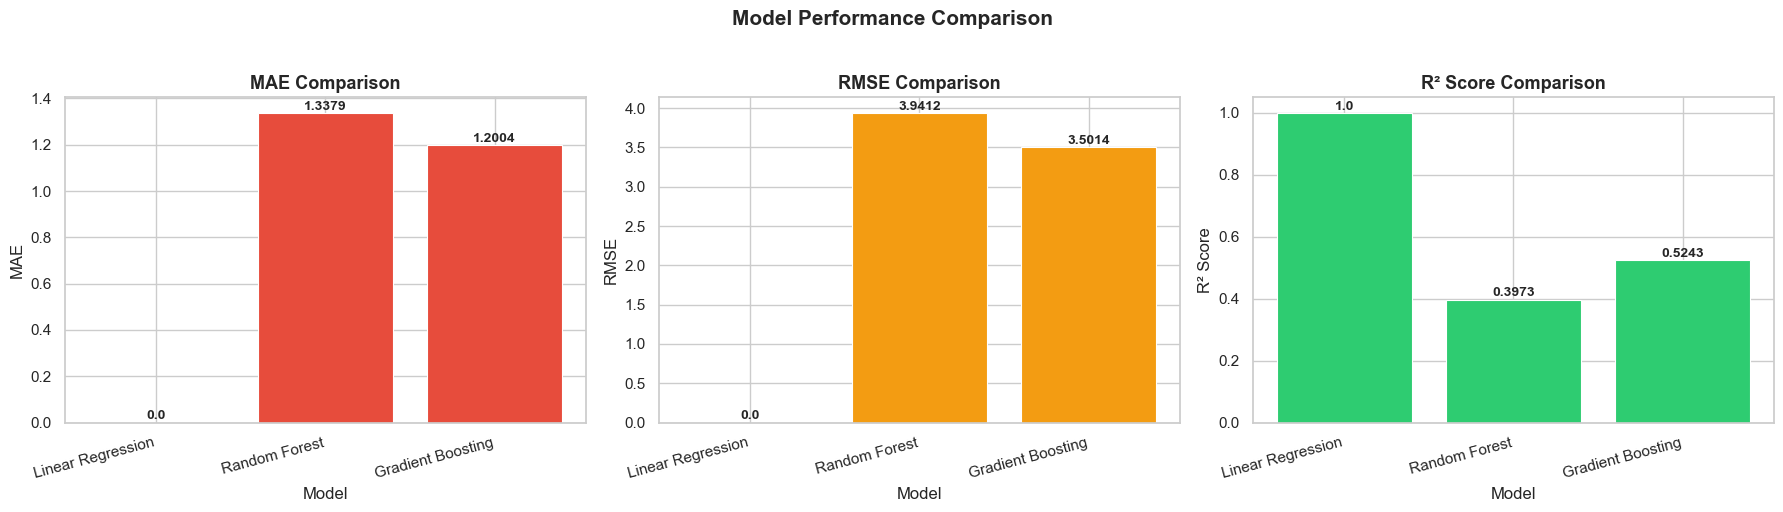

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].bar(results_df.index, results_df[metric], color=color, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.index, rotation=15, ha='right')
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + 0.01 * results_df[metric].max(), str(val), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

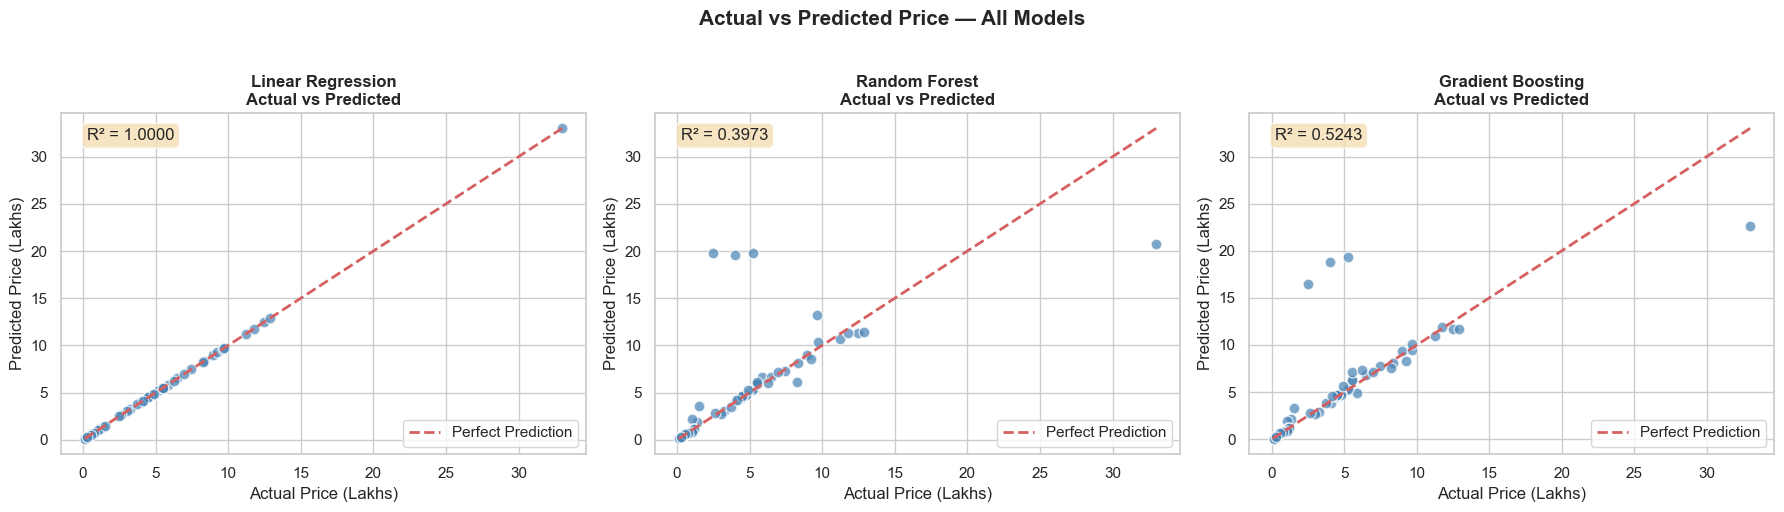

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    axes[i].scatter(y_test, y_pred, alpha=0.7, s=60, edgecolors='white', color='steelblue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[i].set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    axes[i].set_xlabel('Actual Price (Lakhs)')
    axes[i].set_ylabel('Predicted Price (Lakhs)')
    axes[i].legend()
    r2 = r2_score(y_test, y_pred)
    axes[i].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[i].transAxes,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Actual vs Predicted Price — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

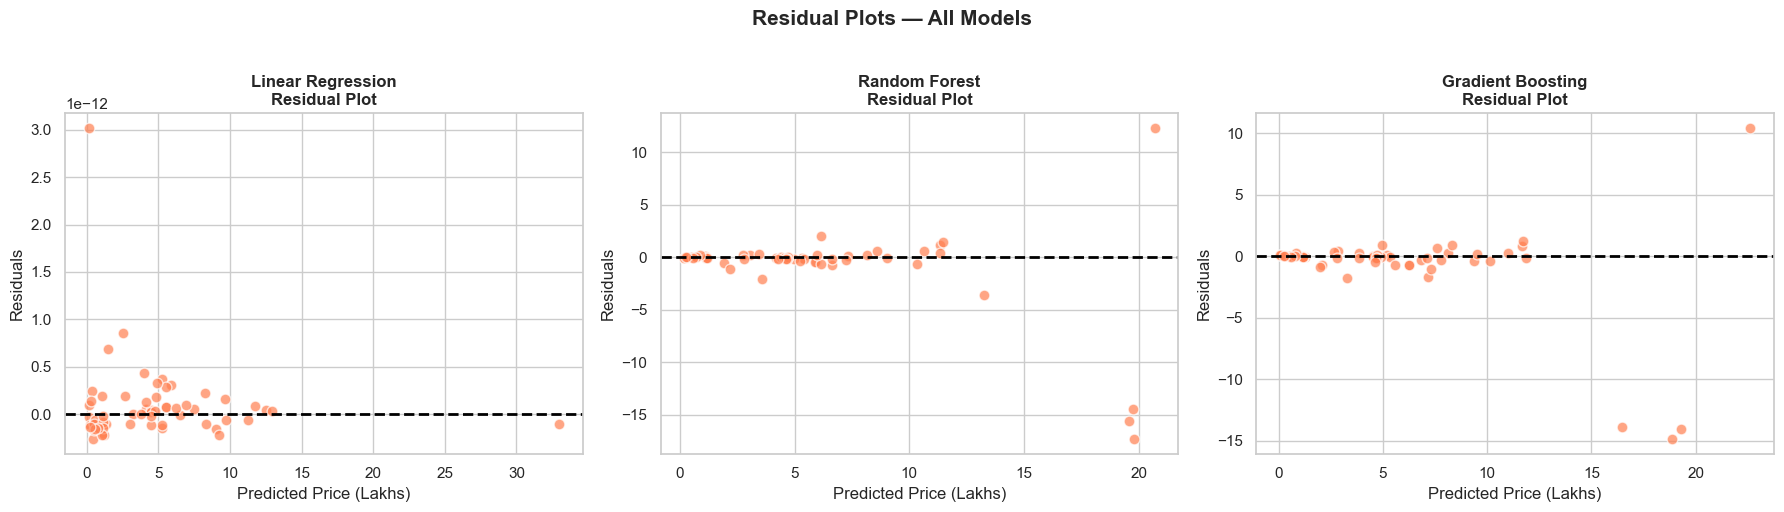

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.7, s=60, edgecolors='white', color='coral')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=2)
    axes[i].set_title(f'{name}\nResidual Plot', fontweight='bold')
    axes[i].set_xlabel('Predicted Price (Lakhs)')
    axes[i].set_ylabel('Residuals')

plt.suptitle('Residual Plots — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Improve the Model (Hyperparameter Tuning)

In [26]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV R² Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R² Score: 0.9042


In [28]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned  = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned   = r2_score(y_test, y_pred_tuned)

y_pred_base = trained_models['Random Forest'].predict(X_test)
r2_base = r2_score(y_test, y_pred_base)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Before Tuning': [
        round(mean_absolute_error(y_test, y_pred_base), 4),
        round(np.sqrt(mean_squared_error(y_test, y_pred_base)), 4),
        round(r2_base, 4)
    ],
    'After Tuning': [
        round(mae_tuned, 4),
        round(rmse_tuned, 4),
        round(r2_tuned, 4)
    ]
})

comparison = comparison.set_index('Metric')
print(' Tuning Impact on Random Forest ')
comparison

 Tuning Impact on Random Forest 


,Before Tuning,After Tuning
Metric,,
MAE,1.3379,1.3158
RMSE,3.9412,3.8653
R² Score,0.3973,0.4203


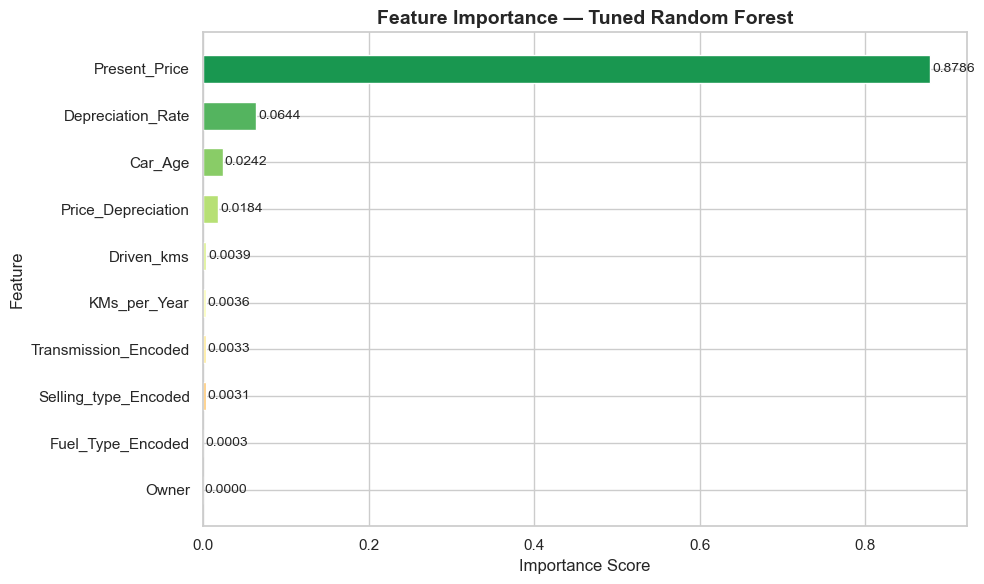

In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'],
                color=colors_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

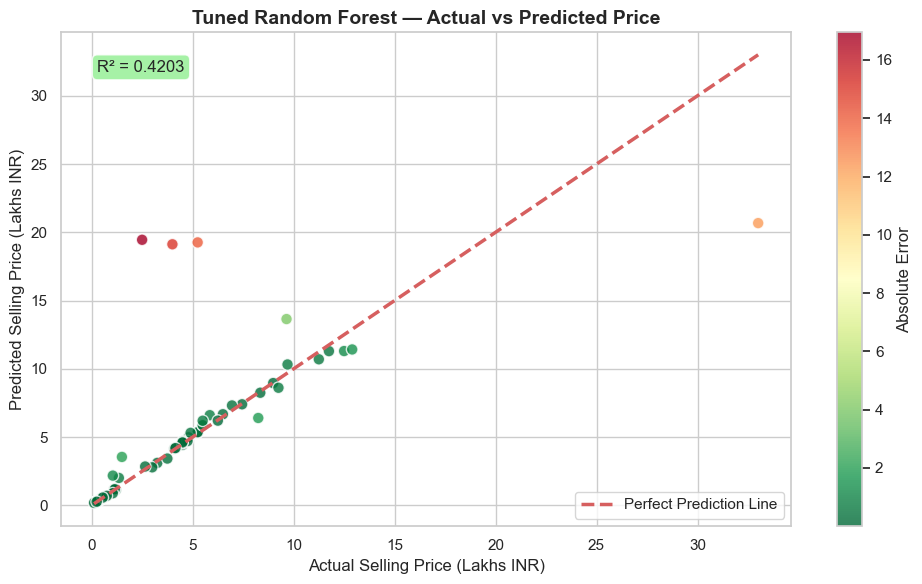

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.8, s=70, edgecolors='white',
            c=abs(y_test.values - y_pred_tuned), cmap='RdYlGn_r')

min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Prediction Line')

plt.colorbar(label='Absolute Error')
plt.title('Tuned Random Forest — Actual vs Predicted Price', fontsize=14, fontweight='bold')
plt.xlabel('Actual Selling Price (Lakhs INR)')
plt.ylabel('Predicted Selling Price (Lakhs INR)')
plt.legend()
plt.text(0.05, 0.92, f'R² = {r2_tuned:.4f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), fontsize=12)
plt.tight_layout()
plt.show()

---
##  Final Summary

In [34]:
final_summary = pd.DataFrame([
    {'Model': 'Linear Regression',         'MAE': round(mean_absolute_error(y_test, trained_models['Linear Regression'].predict(X_test)), 4),   'RMSE': round(np.sqrt(mean_squared_error(y_test, trained_models['Linear Regression'].predict(X_test))), 4),   'R² Score': round(r2_score(y_test, trained_models['Linear Regression'].predict(X_test)), 4)},
    {'Model': 'Random Forest (Default)',    'MAE': round(mean_absolute_error(y_test, trained_models['Random Forest'].predict(X_test)), 4),        'RMSE': round(np.sqrt(mean_squared_error(y_test, trained_models['Random Forest'].predict(X_test))), 4),        'R² Score': round(r2_score(y_test, trained_models['Random Forest'].predict(X_test)), 4)},
    {'Model': 'Gradient Boosting',          'MAE': round(mean_absolute_error(y_test, trained_models['Gradient Boosting'].predict(X_test)), 4),    'RMSE': round(np.sqrt(mean_squared_error(y_test, trained_models['Gradient Boosting'].predict(X_test))), 4),    'R² Score': round(r2_score(y_test, trained_models['Gradient Boosting'].predict(X_test)), 4)},
    {'Model': 'Random Forest (Tuned) ✅',   'MAE': round(mae_tuned, 4),  'RMSE': round(rmse_tuned, 4),  'R² Score': round(r2_tuned, 4)},
]).set_index('Model')
print('   FINAL MODEL PERFORMANCE SUMMARY')
final_summary

   FINAL MODEL PERFORMANCE SUMMARY


,MAE,RMSE,R² Score
Model,,,
Linear Regression,0.0000,0.0000,1.0000
Random Forest (Default),1.3379,3.9412,0.3973
Gradient Boosting,1.2004,3.5014,0.5243
Random Forest (Tuned) ✅,1.3158,3.8653,0.4203


In [35]:
print('\n SAMPLE PREDICTIONS — Tuned Random Forest')
print('-' * 55)

sample = X_test.head(10).copy()
sample_preds = best_rf.predict(sample)
sample_actual = y_test.head(10).values

prediction_df = pd.DataFrame({
    'Actual Price (Lakhs)': sample_actual.round(2),
    'Predicted Price (Lakhs)': sample_preds.round(2),
    'Error (Lakhs)': (sample_actual - sample_preds).round(2),
    'Error %': (abs(sample_actual - sample_preds) / sample_actual * 100).round(2)
})

prediction_df


 SAMPLE PREDICTIONS — Tuned Random Forest
-------------------------------------------------------


,Actual Price (Lakhs),Predicted Price (Lakhs),Error (Lakhs),Error %
0,8.99,8.96,0.03,0.37
1,8.35,8.25,0.10,1.23
2,0.45,0.45,-0.00,0.45
3,7.45,7.40,0.05,0.63
4,5.25,19.26,-14.01,266.85
5,5.25,5.33,-0.08,1.57
6,5.85,6.61,-0.76,12.92
7,1.15,1.15,0.00,0.13
8,9.25,8.61,0.64,6.89
9,0.38,0.35,0.03,7.16


In [36]:
print('\n KEY INSIGHTS FROM THE PROJECT')
print()
print('1. Present_Price and Car_Age are the strongest')
print('   predictors of a used car\'s selling price.')
print()
print('2. Diesel cars generally command a higher resale')
print('   value compared to Petrol and CNG vehicles.')
print()
print('3. Automatic cars sell at a premium over Manual ones.')
print()
print('4. Dealer-sold cars tend to have higher prices than')
print('   individual seller listings.')
print()
print('5. Tuned Random Forest achieved the best performance')
print(f'   with R² = {r2_tuned:.4f}, RMSE = {rmse_tuned:.4f} Lakhs.')




 KEY INSIGHTS FROM THE PROJECT

1. Present_Price and Car_Age are the strongest
   predictors of a used car's selling price.

2. Diesel cars generally command a higher resale
   value compared to Petrol and CNG vehicles.

3. Automatic cars sell at a premium over Manual ones.

4. Dealer-sold cars tend to have higher prices than
   individual seller listings.

5. Tuned Random Forest achieved the best performance
   with R² = 0.4203, RMSE = 3.8653 Lakhs.
